<a href="https://colab.research.google.com/github/MazoelleOliveira/Analise-diversidade-2022/blob/main/Regressao_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mod 7 -Feature Engineering- Preparação dos dados- parte 1

Ei, Astronautas💜 Nesta aula nós continuamos a parte de pré processamento dos dados, dessa vez focando no Feature Engineering🖥️

O modelo de regressão que faremos nesse módulo será apenas com os dados das pessoas que estão empregadas do tipo CLT.

➡️Então filtramos da coluna de “QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?” todas as pessoas que marcaram a opção “Empregado (CLT)”.

➡️Depois disso criamos uma coluna chamada “NÃO_BRANCA”, aonde, se na coluna de “COR/RACA/ETNIA” for “branca” essa coluna recebe 0, e caso contrário recebe 1.

➡️Vamos para a coluna de “QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?” e usamos a função extract para pegar o primeiro dígito que aparece em cada opção dessa coluna. Aplicamos o mesmo para a coluna de “NÚMERO DE FUNCIONÁRIOS”.

In [ ]:
import pandas as pd


In [ ]:
dados=pd.read_excel('/content/drive/MyDrive/Materiais e arquivos/Materiais importantes /Curso Programaria /Arquivos/analise_dados_mod7_(1).xlsx')

In [ ]:
dados.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,0.0,0.0
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,1.0,0.0
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,0.0,1.0
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,0.0,1.0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,0.0,1.0


In [ ]:
#Vamos filtrar tudo o que seja igual a empregado CLT:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762
Empreendedor ou Empregado (CNPJ),410
"Desempregado, buscando recolocação",350
Estagiário,188
Servidor Público,156
Trabalho na área Acadêmica/Pesquisador,86
Somente Estudante (graduação),82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil,69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil,46


In [ ]:
dados = dados[dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'] == 'Empregado (CLT)']

In [ ]:
#Funcionou, veja:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762


In [ ]:
#Agora, vamos fazer isso com raça cor e etnia, e tirar essas colunas com poucos dados, como a coluna indígena (só 4, a amostra é muito pequena), Prefiro não informar e Outra:
dados['COR/RACA/ETNIA'].value_counts()

,count
COR/RACA/ETNIA,
Branca,1805
Parda,661
Preta,181
Amarela,85
Prefiro não informar,16
Outra,10
Indígena,4


In [ ]:
lista_retirar = ['Prefiro não informar', 'Outra', 'Indígena']

In [ ]:
#Usando o isin pra filtrar e o ~ pra retirar de dados tudo o que está em  lista_retirar:
dados = dados[~dados['COR/RACA/ETNIA'].isin(lista_retirar)]

In [ ]:
#Criando uma coluna não-branca usando apply:
dados['NAO_BRANCA'] = dados['COR/RACA/ETNIA'].apply(lambda x: 1 if x != 'Branca' else 0)

In [ ]:
#outro atributo a ser utilizado é o tempo de experiência:
dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts()

,count
QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,
de 1 a 2 anos,743
de 3 a 4 anos,584
de 4 a 6 anos,416
Menos de 1 ano,353
Mais de 10 anos,277
de 7 a 10 anos,232
Não tenho experiência na área de dados,127


In [ ]:
#usando a função extract, pra ter somente números e não mais as frases:
dados['TEMPO_EXPERIENCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)') #o r (regex) antes das aspas indica uma string crua, antes da raiz, e o /d é um metacaracter e o + indica 1 ou + dígitos)
dados['TEMPO_EXPERIENCIA'].value_counts()

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232


In [ ]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
#Agora, com o mesmo com a coluna Número de Funcionários:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

,count
NUMERO DE FUNCIONARIOS,
3000,1313
101,503
1001,368
501,248
51,146
11,112
6,24
1,18


In [ ]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.replace('.', '')

In [ ]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

,count
NUMERO DE FUNCIONARIOS,
Acima de 3000,1313
de 101 a 500,503
de 1001 a 3000,368
de 501 a 1000,248
de 51 a 100,146
de 11 a 50,112
de 6 a 10,24
de 1 a 5,18


In [ ]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

In [ ]:
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

,count
NUMERO DE FUNCIONARIOS,
3000,1313
101,503
1001,368
501,248
51,146
11,112
6,24
1,18


In [ ]:
#agora, com a coluna Tempo de Experiencia:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232
NaN,127


In [ ]:
dados['TEMPO_EXPERIENCIA'] = dados['TEMPO_EXPERIENCIA'].fillna(0)

In [ ]:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232
0,127


In [ ]:
dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].value_counts()

,count
Qual o principal motivo da sua insatisfação com a empresa atual?,
Gostaria de trabalhar em em outra área de atuação,69
Salário atual não corresponde ao mercado,53
Falta de oportunidade de crescimento no emprego atual,46
Falta de maturidade analítica na empresa,45
"Falta de oportunidade de crescimento no emprego atual, Salário atual não corresponde ao mercado, Falta de maturidade analítica na empresa",26
...,...
"O clima de trabalho/ambiente não é bom, Não tenho uma boa relação com meu líder/gestor, Gostaria de receber mais benefícios",1
Falta de organização nos processos internos,1
"Gostaria de receber mais benefícios, O clima de trabalho/ambiente não é bom, Falta de oportunidade de crescimento no emprego atual",1


In [ ]:
dados['INSATISFACAO']= 0

In [ ]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x:1 if 'Salário' in x else 0)

,Qual o principal motivo da sua insatisfação com a empresa atual?
1,0
2,0
7,1
10,0
26,1
...,...
4227,0
4234,1
4238,0
4240,1


In [ ]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'INSATISFACAO']= dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x:1 if 'Salário' in x else 0)

In [ ]:
dados['INSATISFACAO'].value_counts()

,count
INSATISFACAO,
0,2453
1,279


In [ ]:
dados['NIVEL DE ENSINO'].value_counts()

,count
NIVEL DE ENSINO,
Graduação/Bacharelado,1024
Pós-graduação,975
Mestrado,306
Estudante de Graduação,271
Doutorado ou Phd,100
Não tenho graduação formal,52
Prefiro não informar,4


In [ ]:
dados['NIVEL DE ENSINO'] = dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x=='Não tenho graduação formal' else
                               1 if x== 'Estudante de Graduação' else
                               2 if x== 'Graduação/Bacharelado' else
                               3 if x== 'Pós-graduação' else
                               4 if x== 'Mestrado' else
                               5 if x== 'Doutorado' else -1)

Agora, vamos selecionar as colunas que serão usadas como atributos do modelo:

In [ ]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
#Vamos atribuir a dados apenas as colunas novas que vão nos interessar daqui pra frente:
dados = dados[['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO', 'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'NOVO_NIVEL', 'SALARIO', ]]

In [ ]:
dados.columns

Index(['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO',
       'NUMERO DE FUNCIONARIOS', 'NOVO_NIVEL', 'SALARIO'],
      dtype='object')

In [ ]:
#Utilizando o getdummies em algumas colunas que não faz sentido valores numéricos:
dados = pd.get_dummies(dados, columns = ['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'], drop_first=True )

In [ ]:
#Antes de criar o modelo, vamos precisar dividir em duas partes: teste e treino. Primeiro vamos excluir a coluna salário e colocou no target apenas a coluna salario
X = dados.drop('SALARIO', axis = 1)
y = dados['SALARIO']

In [ ]:
#Iniciando a parte de treino importando a função train test split:
from sklearn.model_selection import train_test_split


In [ ]:
# dentro dos parenteses a gente envia os dois primeiros parametros que primeiro sao os atributos e depois os targets
#test_size significa que 20% serao usados para teste e 80% para conjunto de treinamento, radom_state -
#numeros aleatorios, que garante que a divisao dos dados sejam reproduzidos
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
#essa funcao tem como padronizar as caracteristicas,
# removendo a media e escalando para variancia unitaria , traduzindo ela vai normalizar nossos dados
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.fit_transform(x_test)

MOD 7 - 7.3 - Introdução a regressão linear (parte 1)
Oiê, Astronautas. Estamos quase concluindo🤩

➡️Nós importamos a função LinearRegression da biblioteca sklearn, criamos um objeto chamado model apartir dessa função. E então enviando os parâmetros de treino na função fit (assim: model.fit(X_train_scaled, y_train)) nós conseguimos treinar o modelo.

➡️Usando a função predict e enviando como parâmetro o conjunto de teste (X_test_scaled) a gente conseguiu fazer as predições desse conjunto.

➡️E então partimos para uma parte muito importante de qualquer modelo de machine learning que é a avaliação do modelo, para saber se está bom ou ruim (ou mais ou menos, ou médio, ou excelente, ou … enfim, vocês entenderam, certo?😂) Focamos em três métricas principais para avaliação de modelos de regressão:

MSE (Mean Squared Error), MAE (Mean Absolute Error) e R² (R-squared). Com os resultados nós concluímos que para um modelo real de produção nosso modelo não seria aceitável.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
#Criando o objeto da regressão linear:

model = LinearRegression()

In [ ]:
#Prepare-se: vamos treinar o modelo:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
#Vamos fazer as predições do modelo usando a função predict, usando os dados já normalizados
y_pred = model.predict(X_test_scaled)

In [ ]:
#Duas métricas comuns para avaliar erros no modelo de regressão são o erro quadrático médio (MSE) e o coeficiente de determinação
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Primeiro o MSE:
mse = mean_squared_error(y_test, y_pred)
mse

24239832.470045038

In [ ]:
#O MSE deu alto. Vamos calcular agora a MAE:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

In [ ]:
mae

3385.5214004911377

In [ ]:
r2 = r2_score(y_test, y_pred)

In [ ]:
r2

0.5054327070282764

MOD7 - 7.3 - Introdução a regressão linear (parte 2)

E pra finalizar🤩

➡️Plotamos um gráfico dos valores reais versus os valores preditos pelo modelo e conseguimos perceber que até certo valor de salário, os valores preditos e os reais tem uma certa sintonia. Porém para valores muito altos de salários, as predições são muito distantes.

➡️Para conseguir analisar melhor o modelo, nós pegamos os coeficientes (pesos) de cada atributo, assim a gente conseguiu avaliar quais atributos tiveram mais peso positivo ou negativo para o resultado do modelo. Fizemos um gráfico bem bonito pra deixar mais visual essa questão dos coeficientes e conseguimos observar quais atributos pesaram mais para o negativo e quais pesaram mais para o positivo.

➡️Para finalizar, nós fizemos uma reflexão de que o modelo que nós treinamos foi utilizado para análise. Buscando entender no mundo real de hoje o que influencia o salário, olhamos os coeficientes e o que pesa para negativo e positivo.

💭Se um modelo para estimar o salário de uma pessoa, para ser usado na vida real, por exemplo, o salário da equipe da programaria vai ser estimado por um modelo, a gente teria que ter muito cuidado com ética para não reproduzir os vieses do mundo real.

In [ ]:
#Vamos plotar um gráfico pra vermos os valores preditos pelo modelo:
import matplotlib.pyplot as plt

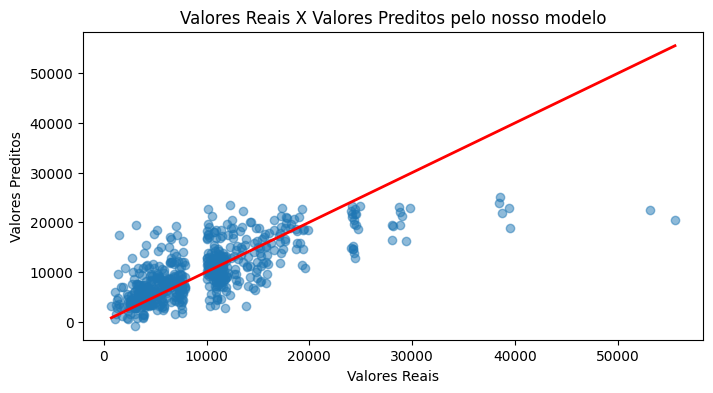

In [ ]:
#As bolinhas azuis são os salarios, podemos ver que até aproximadamente 20.000 de salário estamos próximos, depois modifica
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha = 0.5)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Preditos')
plt.title('Valores Reais X Valores Preditos pelo nosso modelo')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.show()

In [ ]:
nomes_atributos = x_train.columns
nomes_atributos

Index(['IDADE', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'GENERO_Masculino',
       'GENERO_Prefiro não informar', 'SETOR_Educação',
       'SETOR_Entretenimento ou Esportes', 'SETOR_Filantropia/ONG's',
       'SETOR_Finanças ou Bancos', 'SETOR_Indústria',
       'SETOR_Internet/Ecommerce', 'SETOR_Marketing', 'SETOR_Outra Opção',
       'SETOR_Seguros ou Previdência', 'SETOR_Setor Alimentício',
       'SETOR_Setor Automotivo', 'SETOR_Setor Farmaceutico',
       'SETOR_Setor Imobiliário/ Construção Civil', 'SETOR_Setor Público',
       'SETOR_Setor de Energia', 'SETOR_Tecnologia/Fábrica de Software',
       'SETOR_Telecomunicação', 'SETOR_Varejo', 'SETOR_Área da Saúde',
       'SETOR_Área de Consultoria', 'NOVO_NIVEL_Pessoa Gestora',
       'NOVO_NIVEL_Pleno', 'NOVO_NIVEL_Sênior', 'REGIAO ONDE MORA_Nordeste',
       'REGIAO ONDE MORA_Norte', 'REGIAO ONDE MORA_Sudeste',
       'REGIAO ONDE MORA_Sul'],
      dtype='object')

In [ ]:
coefs = pd.DataFrame(model.coef_, columns=['coeficientes'], index= nomes_atributos)

In [ ]:
#Vamos ordenar a coluna de coeficientes pra ver o que está influenciando mais e menos:
coefs=coefs.sort_values(by='coeficientes', ascending=False)

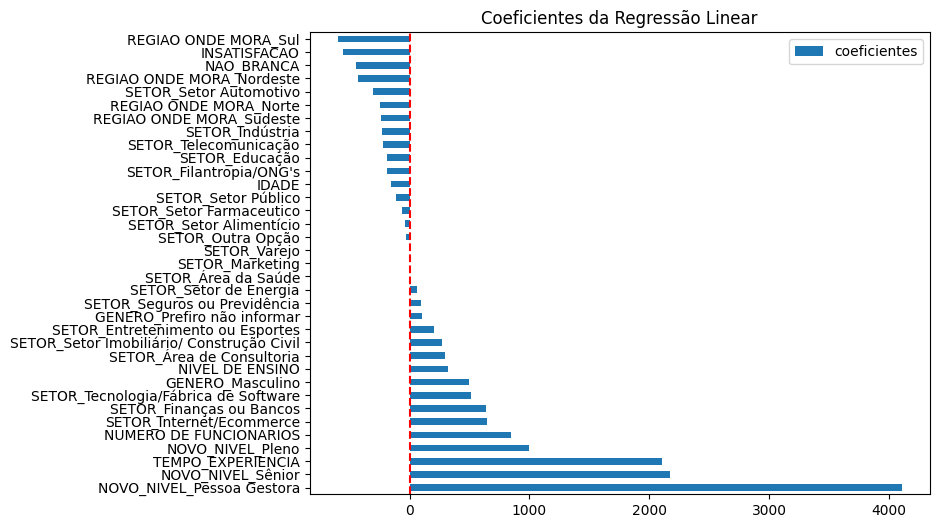

In [ ]:
coefs.plot.barh(figsize=(8,6))
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Coeficientes da Regressão Linear')
plt.show()